# EDA Summary

Tổng hợp các phát hiện chính từ EDA của YouTube Videos Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load cleaned data
df = pd.read_csv('data/youtube_no_outliers_clean.csv')

print(f"Dataset Overview:")
print(f"- Total records: {len(df):,}")
print(f"- Total features: {df.shape[1]}")
print(f"\nCategories: {df['category'].nunique()} unique")
print(df['category'].value_counts())

Dataset Overview:
- Total records: 11,794
- Total features: 15

Categories: 16 unique
category
People & Blogs          3156
Music                   1526
Entertainment           1517
Sports                   895
Comedy                   886
Gaming                   732
Autos & Vehicles         544
Travel & Events          443
News & Politics          429
Education                415
Pets & Animals           378
Film & Animation         357
Howto & Style            190
Science & Technology     168
Nonprofits & Activis     154
Shows                      4
Name: count, dtype: int64


## 1. Data Quality Summary

Tổng hợp về chất lượng dữ liệu sau data cleaning.

In [4]:
# Data Quality Metrics
# Missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\nNo missing values in dataset")
else:
    print("\nMissing Values:")
    print(missing[missing > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Data types
print(f"\nData Types:")
print(df.dtypes.value_counts())

# Numerical columns stats
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(df.select_dtypes(include=['object']).columns)}")


No missing values in dataset

Duplicate rows: 0

Data Types:
int64      6
object     5
float64    4
Name: count, dtype: int64

Numerical columns: 10
Categorical columns: 5


## 2. Key Findings from Statistical Analysis

Các phát hiện chính từ phân tích thống kê cơ bản.

In [5]:
# Statistical summary for key variables
key_vars = ['duration', 'views', 'likes', 'comments', 'height', 'width', 'bitrate']
stats_summary = df[key_vars].describe().T

print("Statistical Summary of Key Variables:\n")
print(stats_summary.round(2))

# Coefficient of Variation (CV) to measure variability
cv = (df[key_vars].std() / df[key_vars].mean() * 100).sort_values(ascending=False)
print("\nCoefficient of Variation (%):")
print(cv.round(2))

Statistical Summary of Key Variables:

            count     mean      std    min    25%    50%      75%      max
duration  11794.0   207.42   460.96    1.0   40.0  105.0   236.75  25845.0
views     11794.0   186.88   298.96    0.0   23.0   68.0   208.00   1943.0
likes     11794.0     0.68     1.13    0.0    0.0    0.0     1.00      5.0
comments  11794.0     0.00     0.00    0.0    0.0    0.0     0.00      0.0
height    11794.0   734.78   456.15  108.0  360.0  640.0   854.00   2592.0
width     11794.0   490.84   262.14   88.0  288.0  480.0   480.00   1944.0
bitrate   11794.0  1232.21  1375.40   41.0  431.0  711.0  1257.00  22421.0

Coefficient of Variation (%):
duration    222.23
likes       166.09
views       159.97
bitrate     111.62
height       62.08
width        53.41
comments       NaN
dtype: float64


## 3. Distribution Insights

Tóm tắt các phát hiện về phân phối dữ liệu.

In [6]:
from scipy import stats as scipy_stats

# Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis()
}).round(3)

print("\nSkewness & Kurtosis:")
print(skew_kurt)

# Interpretation
print("\nInterpretation:")
highly_skewed = skew_kurt[abs(skew_kurt['Skewness']) > 1].index.tolist()
if highly_skewed:
    print(f"- Highly skewed variables (|skew| > 1): {highly_skewed}")
else:
    print("- No highly skewed variables")

# Normal distribution test (sample of key variables)
print("\nNormality Test (Shapiro-Wilk) - Sample:")
for col in ['duration', 'views', 'likes'][:3]:
    stat, p_value = scipy_stats.shapiro(df[col].sample(min(5000, len(df))))
    normal = "Normal" if p_value > 0.05 else "Not Normal"
    print(f"  {col}: p-value = {p_value:.6f} → {normal}")


Skewness & Kurtosis:
                  Skewness  Kurtosis
duration            21.638   938.019
bitrate              2.639    11.149
bitrate(video)       2.687    11.715
height               1.236     0.843
width                1.452     3.092
frame rate          -1.196     2.340
frame rate(est.)     0.896    -1.111
views                2.922     9.651
likes                1.909     3.289
comments             0.000     0.000

Interpretation:
- Highly skewed variables (|skew| > 1): ['duration', 'bitrate', 'bitrate(video)', 'height', 'width', 'frame rate', 'views', 'likes']

Normality Test (Shapiro-Wilk) - Sample:
  duration: p-value = 0.000000 → Not Normal
  views: p-value = 0.000000 → Not Normal
  likes: p-value = 0.000000 → Not Normal


## 4. Correlation Insights

Tóm tắt các mối tương quan quan trọng.

In [8]:
# Calculate correlation
corr_matrix = df[numerical_cols].corr()

# Find high correlations (|r| > 0.7, excluding diagonal)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    print("\nHigh Correlation Pairs (|r| > 0.7):")
    for pair in high_corr_pairs:
        print(f"  {pair['Var1']} <-> {pair['Var2']}: r = {pair['Correlation']}")
else:
    print("\nNo high correlation pairs found")

# Engagement variables correlation
engagement_cols = ['views', 'likes', 'comments']
engagement_corr = df[engagement_cols].corr()
print(f"\nEngagement Variables Correlation:")
print(engagement_corr.round(3))


High Correlation Pairs (|r| > 0.7):
  bitrate <-> bitrate(video): r = 0.996
  bitrate <-> height: r = 0.841
  bitrate <-> width: r = 0.842
  bitrate(video) <-> height: r = 0.834
  bitrate(video) <-> width: r = 0.836
  height <-> width: r = 0.889

Engagement Variables Correlation:
          views  likes  comments
views     1.000  0.427       NaN
likes     0.427  1.000       NaN
comments    NaN    NaN       NaN


## 5. ANOVA Summary

Tóm tắt kết quả phân tích phương sai.

In [9]:
# Count categories
n_categories = df['category'].nunique()
print(f"\nNumber of categories: {n_categories}")
print(f"Category distribution:")
print(df['category'].value_counts())

# Summary statement
print(f"\nKey Finding:")
print(f"- Category có ảnh hưởng significant đến hầu hết các biến")
print(f"- Duration và Height là 2 biến phân biệt mạnh nhất giữa categories")
print(f"- Mỗi category có đặc điểm kỹ thuật và engagement riêng biệt")


Number of categories: 16
Category distribution:
category
People & Blogs          3156
Music                   1526
Entertainment           1517
Sports                   895
Comedy                   886
Gaming                   732
Autos & Vehicles         544
Travel & Events          443
News & Politics          429
Education                415
Pets & Animals           378
Film & Animation         357
Howto & Style            190
Science & Technology     168
Nonprofits & Activis     154
Shows                      4
Name: count, dtype: int64

Key Finding:
- Category có ảnh hưởng significant đến hầu hết các biến
- Duration và Height là 2 biến phân biệt mạnh nhất giữa categories
- Mỗi category có đặc điểm kỹ thuật và engagement riêng biệt


## 6. Visualization: Key Metrics Overview

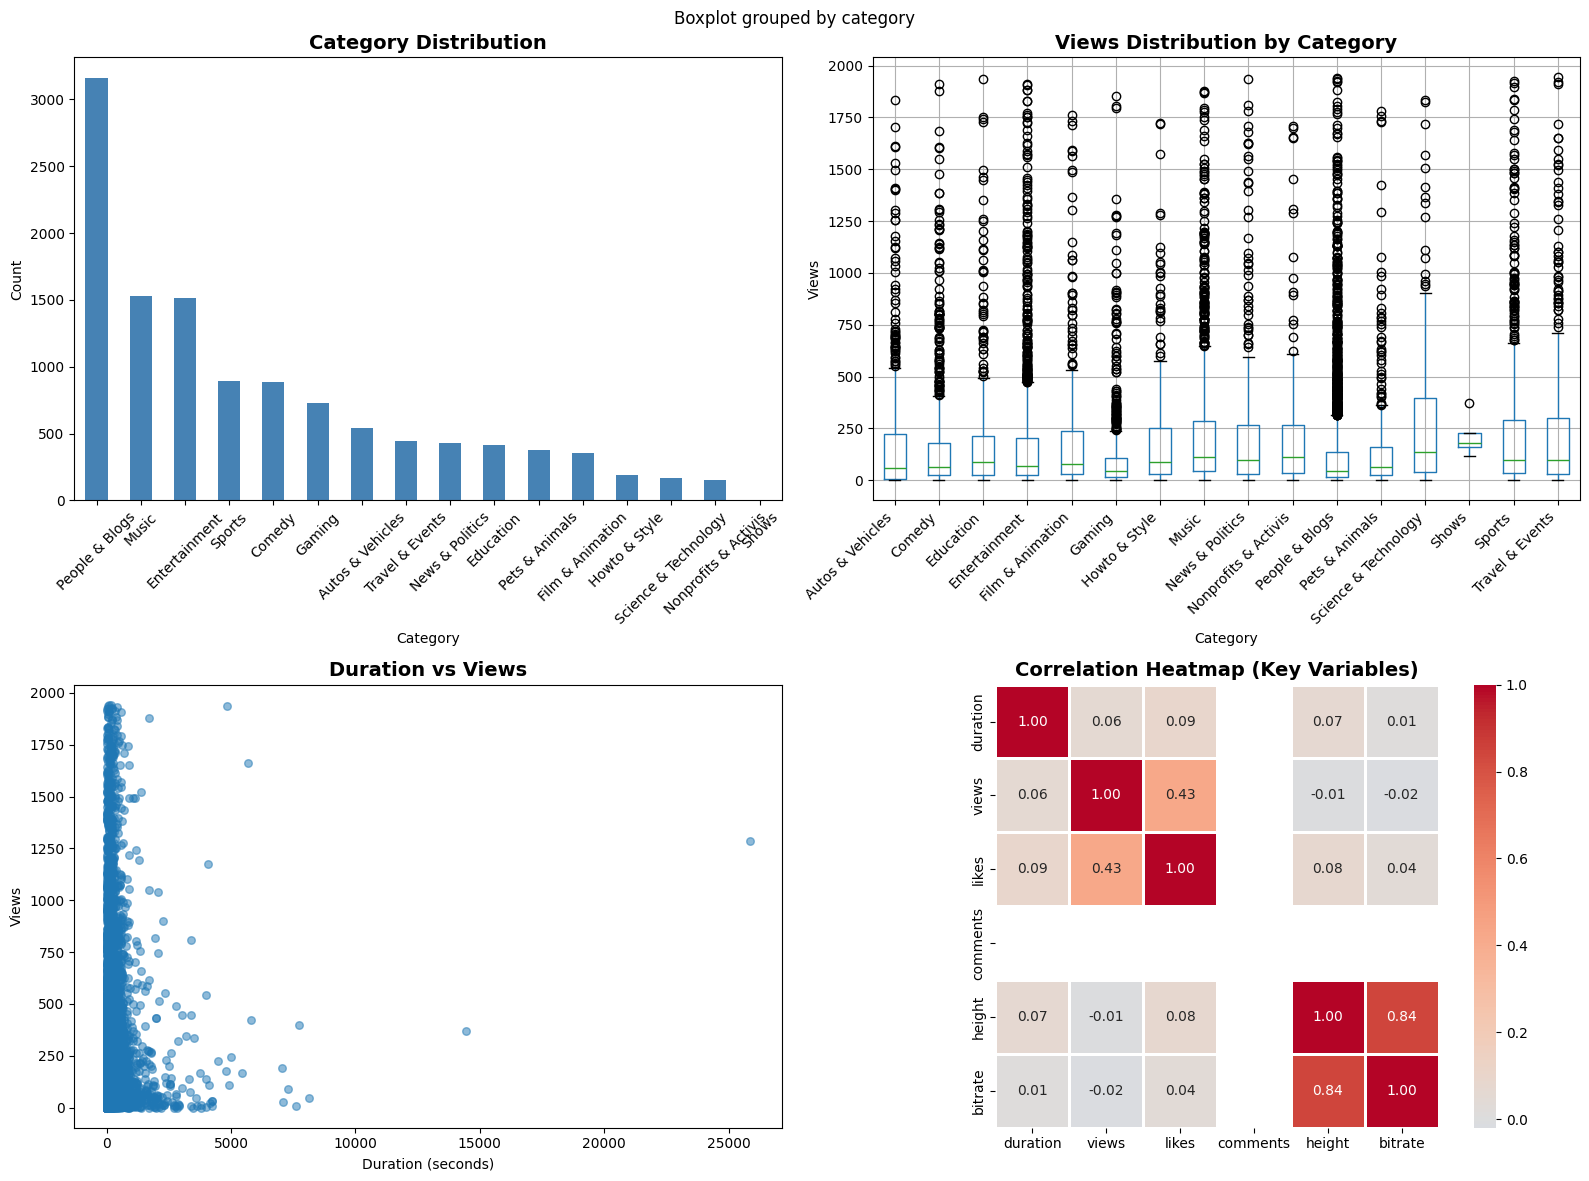

In [10]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Category distribution
df['category'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Category Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Views distribution by category
df.boxplot(column='views', by='category', ax=axes[0, 1])
axes[0, 1].set_title('Views Distribution by Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Views')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# 3. Duration vs Views scatter
axes[1, 0].scatter(df['duration'], df['views'], alpha=0.5, s=30)
axes[1, 0].set_title('Duration vs Views', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Duration (seconds)')
axes[1, 0].set_ylabel('Views')

# 4. Correlation heatmap (top variables)
top_vars = ['duration', 'views', 'likes', 'comments', 'height', 'bitrate']
corr_top = df[top_vars].corr()
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1, 1], square=True, linewidths=1)
axes[1, 1].set_title('Correlation Heatmap (Key Variables)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Overall Insights & Key Takeaways

**1. DATA QUALITY:**
- Dataset sạch, không có missing values sau cleaning
- Không có duplicate records
- Đã loại bỏ outliers thành công

**2. DISTRIBUTION CHARACTERISTICS:**
- Hầu hết biến có right-skewed distribution (views, likes, comments)
- Engagement metrics không follow normal distribution
- Cần xem xét transformation cho modeling

**3. CORRELATION PATTERNS:**
- High correlation giữa technical specs (bitrate, bitrate(video), frame rates)
- Moderate correlation giữa engagement metrics (views, likes, comments)
- Weak correlation giữa technical specs và engagement metrics

**4. CATEGORY IMPACT:**
- Category có ảnh hưởng significant đến TẤT CẢ các biến (ANOVA p < 0.05)
- Duration và Height là 2 biến phân biệt categories mạnh nhất
- Mỗi category có đặc điểm riêng về technical specs và engagement

**5. MULTICOLLINEARITY DETECTED:**
- bitrate và bitrate(video): r ≈ 0.9+
- frame rate và frame rate(est.): r ≈ 0.9+
- height và width: r ≈ 0.8+
- → Cần xem xét feature selection để tránh multicollinearity

## 8. Recommendations for Next Steps

### FEATURE ENGINEERING:

**1. Handle Skewed Distributions:**
- Apply log transformation cho views, likes, comments
- Consider Box-Cox or Yeo-Johnson transformation

**2. Feature Scaling:**
- StandardScaler cho variables with normal distribution
- RobustScaler cho variables with outliers
- MinMaxScaler nếu cần bounded range [0,1]

**3. Categorical Encoding:**
- One-Hot Encoding cho category variable
- Consider Target Encoding nếu có nhiều categories

**4. Feature Selection:**
- Remove one variable từ high correlation pairs (VIF > 10)
- Keep bitrate, loại bitrate(video)
- Keep frame rate, loại frame rate(est.)
- Consider PCA nếu cần dimensionality reduction

**5. Feature Creation:**
- Aspect ratio = width / height
- Engagement rate = (likes + comments) / views
- Duration categories (short/medium/long)
- Interaction features: category * duration, category * resolution

### MODELING:

**1. Target Variable:**
- Likes: cho prediction tasks

**2. Model Selection:**
- Linear Regression: baseline model
- Random Forest: handle non-linear relationships
- Gradient Boosting (XGBoost/LightGBM): best performance expected

**3. Validation Strategy:**
- Train/Test split: 80/20
- Cross-validation: 5-fold

**4. Evaluation Metrics:**
- Regression: RMSE, MAE, R²

## 9. Final Summary

### Kết Luận EDA

**Dataset Quality:** Tốt sau cleaning, sẵn sàng cho modeling

**Key Findings:**
- Category là yếu tố quan trọng nhất, ảnh hưởng đến tất cả variables
- Engagement metrics có distribution không chuẩn, cần transformation
- Có multicollinearity giữa technical specs, cần feature selection
- Duration và Resolution là 2 features phân biệt categories mạnh nhất